<img src="../logoutn.jpg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 9

Farcy Facundo

# Consignas

## Ítem 1
<img src="Consigna_1.png"/> 

## Ítem 2
<img src="Consigna_2.png"/> 

# RESOLUCIÓN

## Preparación previa

In [13]:
# %% INICIALIZACION
# Inicialización e importación de módulos

# Módulos para Jupyter
import warnings
warnings.filterwarnings('ignore')

# Módulos importantantes
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla, GroupDelay, bodePlot, pzmap
import matplotlib.gridspec as gridspec
# Tamaño de las figuras
fig_sz_x = 14
fig_sz_y = 7

# Tamaño de la tipografía
fig_font_size = 16

plt.rcParams.update({'font.size':fig_font_size})

###
## Señal de ECG registrada a 1 kHz, con contaminación de diversos orígenes.
###

# para listar las variables que hay en el archivo
#io.whosmat('ecg.mat')

mat_struct = sio.loadmat('ecg.mat')

ecg_one_lead = mat_struct['ecg_lead']
ecg_one_lead = ecg_one_lead.flatten()
cant_muestras = len(ecg_one_lead)

#---

## Ítem 1 

### <u>Parámetros</u>

In [14]:

fs = 1000 # Hz
nyq_frec = fs / 2

ripple = 0.5 # dB
atenuacion = 40 # dB

ws1 = .1 #Hz
wp1 = 1 #Hz
wp2 = 35.0 #Hz
ws2 = 45.0 #Hz

wp_iir = [wp1, wp2]
ws_iir = [ws1, ws2]

### <u>Diseño IIR</u>
Con la función iirdesign, implemento un filtro elíptico.

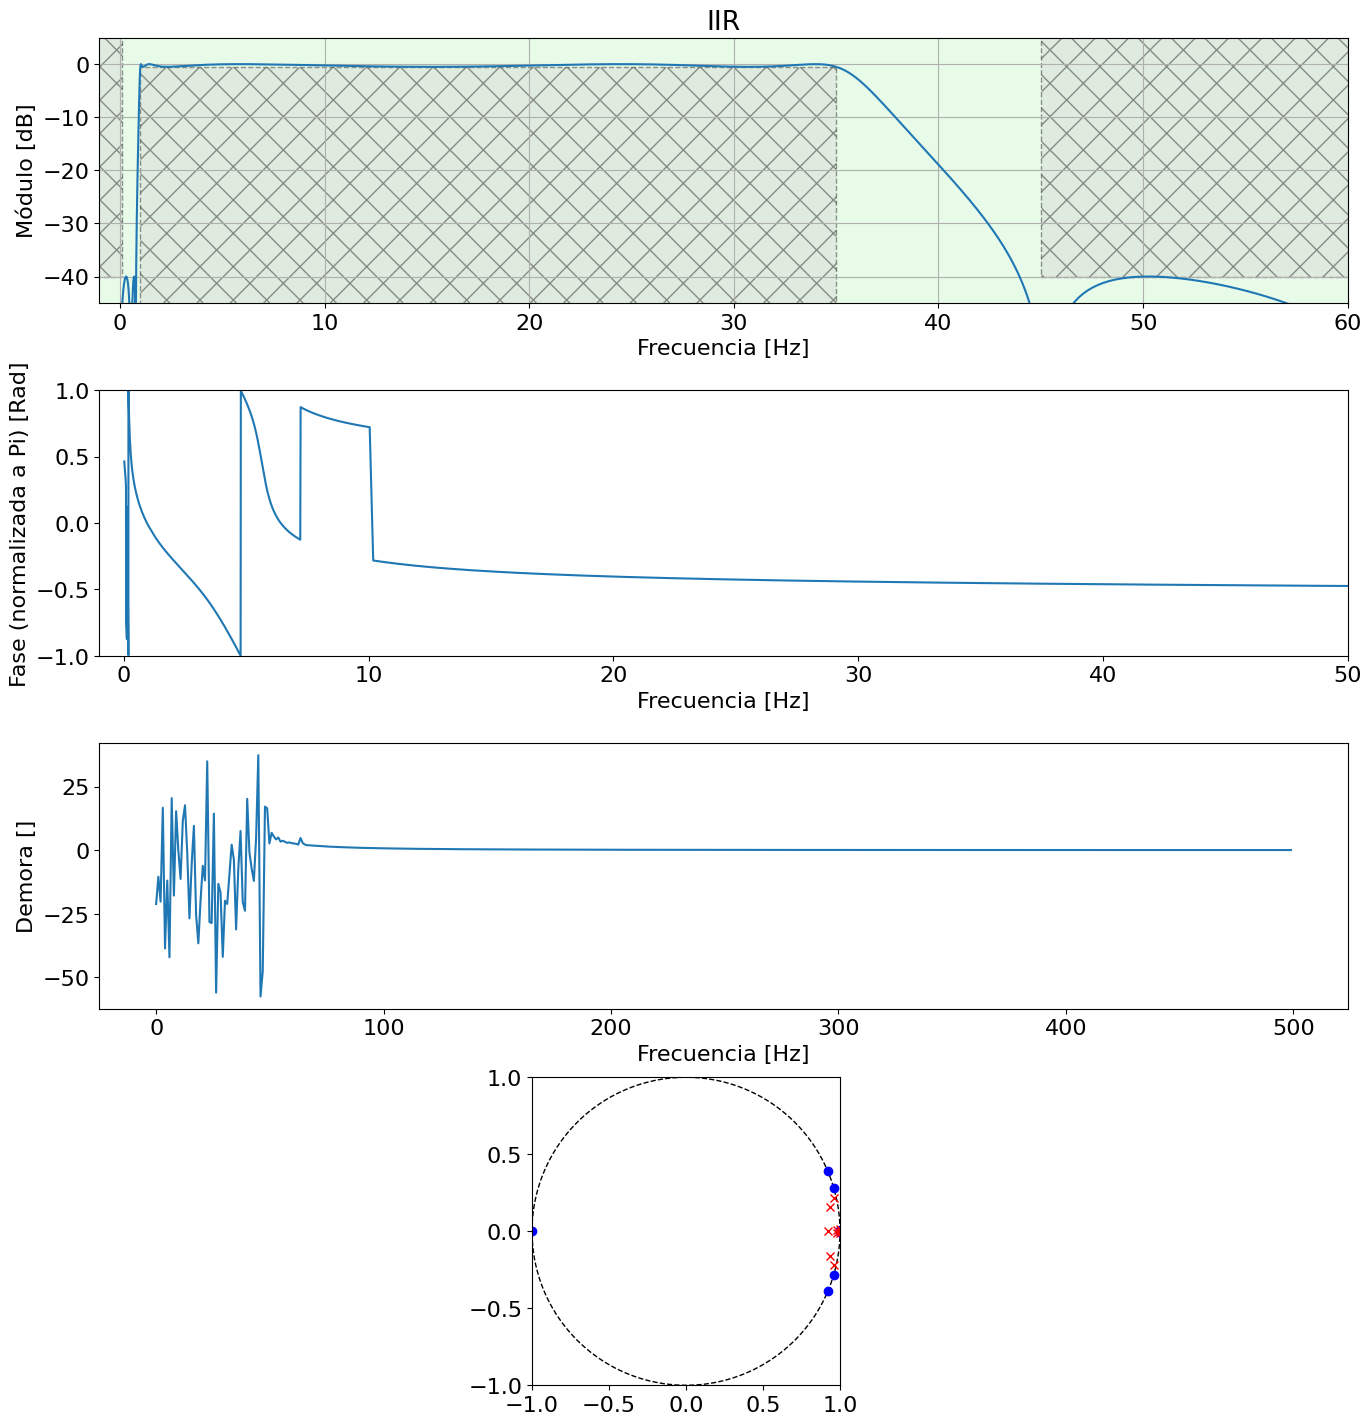

In [46]:
sos_iir_ellip = sig.iirdesign(wp= wp_iir, ws=ws_iir, gpass=ripple, gstop=atenuacion, output='sos', analog=False, ftype='ellip', fs = fs)
tf_iir_ellip = sig.sos2tf(sos_iir_ellip)

w_rad  = np.append(np.logspace(-1, 0.8, 1000), np.logspace(0.9, 1.8, 1000) )
w_rad  = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True) )

w_rad_ellip, h_iir_ellip = sig.freqz_sos(sos_iir_ellip, worN=w_rad, fs = fs)

fig_1 = plt.figure(1, figsize=(fig_sz_x, fig_sz_y*2))

fig_1.add_subplot(4,1,1)
plt.plot(w_rad, 20*np.log10(np.abs(h_iir_ellip)+1e-12), label = 'ELLIP' )
plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
plt.title('IIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([-1, 60, -45, 5]);

fig_1.add_subplot(4,1,2)
plt.plot(w_rad/(2*np.pi), np.unwrap(np.angle(h_iir_ellip)/np.pi), label = 'PHASE' )
plt.axis([-1, 50, -1, 1]);
plt.xlabel("Frecuencia [Hz]")
plt.ylabel('Fase (normalizada a Pi) [Rad]')

#Demora
w, gd = sig.group_delay((tf_iir_ellip[0], tf_iir_ellip[1]), fs=fs)
fig_1.add_subplot(4,1,3)
plt.plot(w, gd, label="DEMORA")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel('Demora []')
# Polos y ceros
z, p, k = sig.tf2zpk(tf_iir_ellip[0], tf_iir_ellip[1])
axe_4 = fig_1.add_axes([0.39, 0., 0.22, 0.22])  # [x0, y0, ancho, alto] en fracción de la figura
axe_4.set_aspect('equal')
theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1)
plt.plot(np.real(z), np.imag(z), 'ob', label='Ceros')
plt.plot(np.real(p), np.imag(p), 'xr', label='Polos')
plt.axis([-1,1,-1,1])

plt.tight_layout() #Corrije espaciado entre subplots

